In [1]:
library(deSolve)
library(ggplot2)
source("GLV_functions.R")
source("Functions.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘igraph’


The following objects are masked from ‘package:lubridate’:

    %--%, union


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:purrr’:

    compose, simplify


The following object is masked from ‘package:tidyr’:

    crossing


The following object is masked from ‘package:tibble’:

    as_data_frame


The following objects are masked from ‘package:stats’:

    decompose, spec

# Dinámicas de poblaciones

## Discretas

### 1 Especie aislada
Vamos a comenzar modelando una población de una especie aislada que se reproduce anualmente. La regla que seguimos es que solo se reproduce una vez al año, cada año.

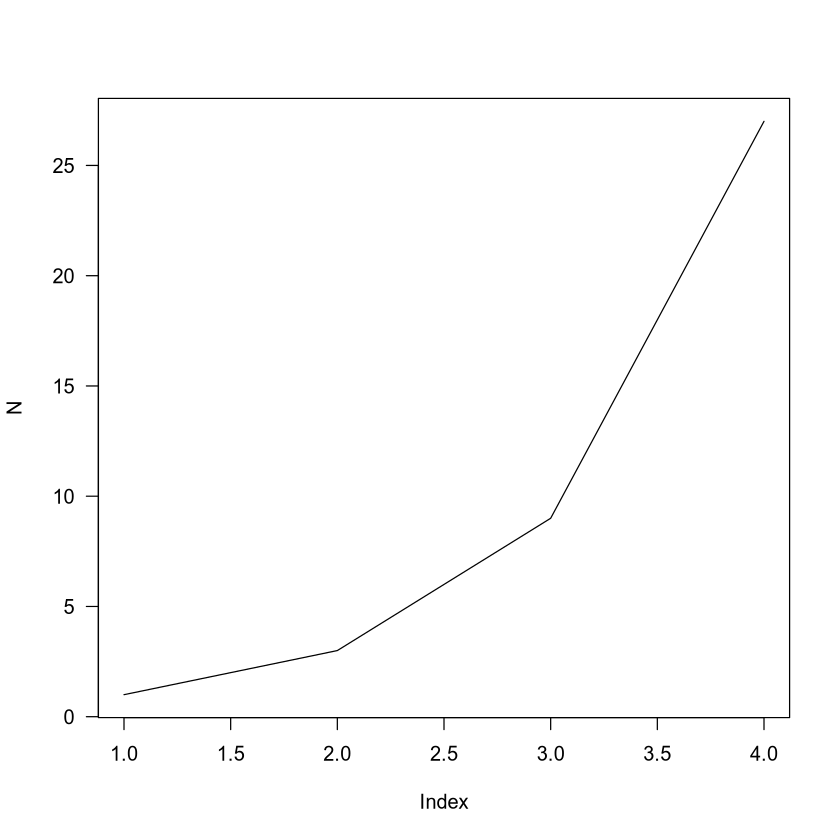

In [2]:
#creamos nuestra función:
crecimiento1 <- function(N0 = 1, r = 2, tiempo = 4){
#la función tiene tres parametros, N0, r y el tiempo a simular.
N <- rep(NA,tiempo) #creamos un vector vacio (NA = Not Available) para guardar el valor de N para cada tiempo
N[1] <- N0 # asignamos N0 al primer valor (el uno que esta dentro del corchete lo indica)
for(i in 2:tiempo){ #para asignar el resto de valores, usaremos un bucle
N[i] <- N[i-1] + r*N[i-1] #resolvemos la equación para cada tiempo.
}
plot(N, t = "l", las = 1) #graficamos.
}
#nota: normalmente se resuelve la derivada de N sobre t (en continuo), pero es mucho más claro de forma
crecimiento1(tiempo=4) #a partir del año 40 tenemos >1000 individuos. Recuerda que hemos fijado r a 0.1, es dec

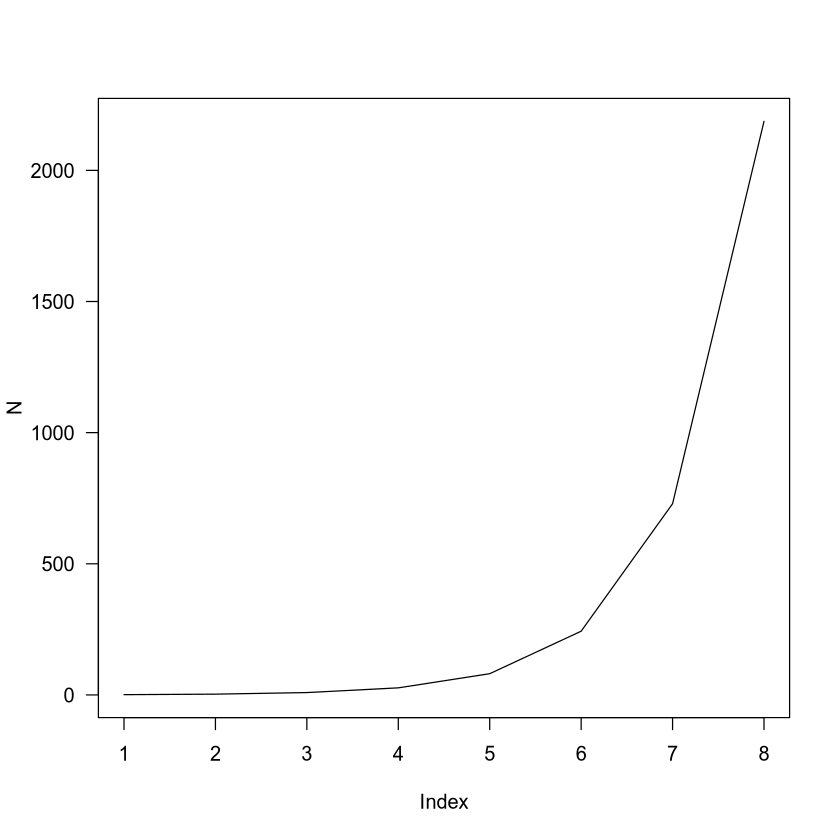

In [3]:
crecimiento1(tiempo=8)

Pasamos de tener poco mas de 25 individuos en 4 años a tene ,as de 2000 en 8 años. Cada año TRIPLICA la población

### 1 Especie aislada auto-regulada

Las poblaciones no pueden crecer de forma libre por un tiempo infinito, ya que que antes o depués encontrará un límite. Esto lo metemos con el término $(1 - N[i-1]/k)$ que multiplica a la $r$. Ahora no tenemos un ratio de reproducción constante ($r$), sino que la reproducción va a depender de la población, será un $r'=r(1-N[i-1]/K)$. 

Cuando N sea pequeño, $r'=r$, pero cuando $N=K$, entonces $r'=0$

In [4]:
crecimiento2 <- function(N1 = 30, r = 0.1, k = 300, tiempo = 100){
#añadimos el parametro k (individuos máximos)
N <- rep(NA,tiempo) #creamos vector vacio
N[1] <- N1 #le damos la población inicial
for(i in 2:tiempo){ #bucle para calcular N en cada año i
N[i] <- N[i-1] + r*N[i-1] * (1 - N[i-1]/k) #nuestra equación
}
plot(N, t = "l", las = 1) #graficar
}

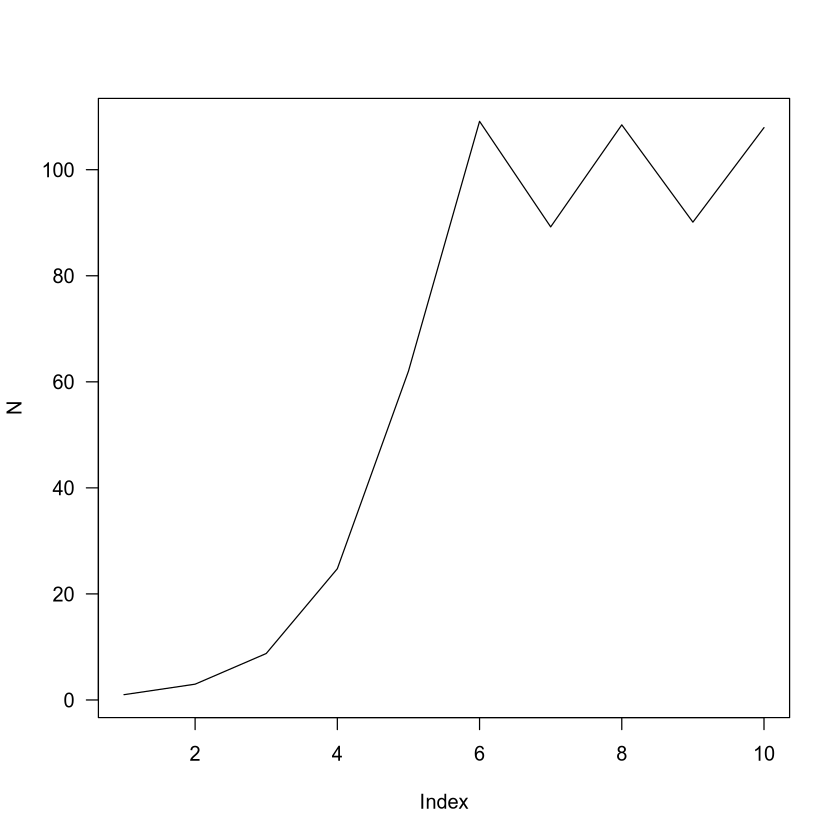

In [5]:
crecimiento2(N1=1,r=2,k=100,tiempo = 10)

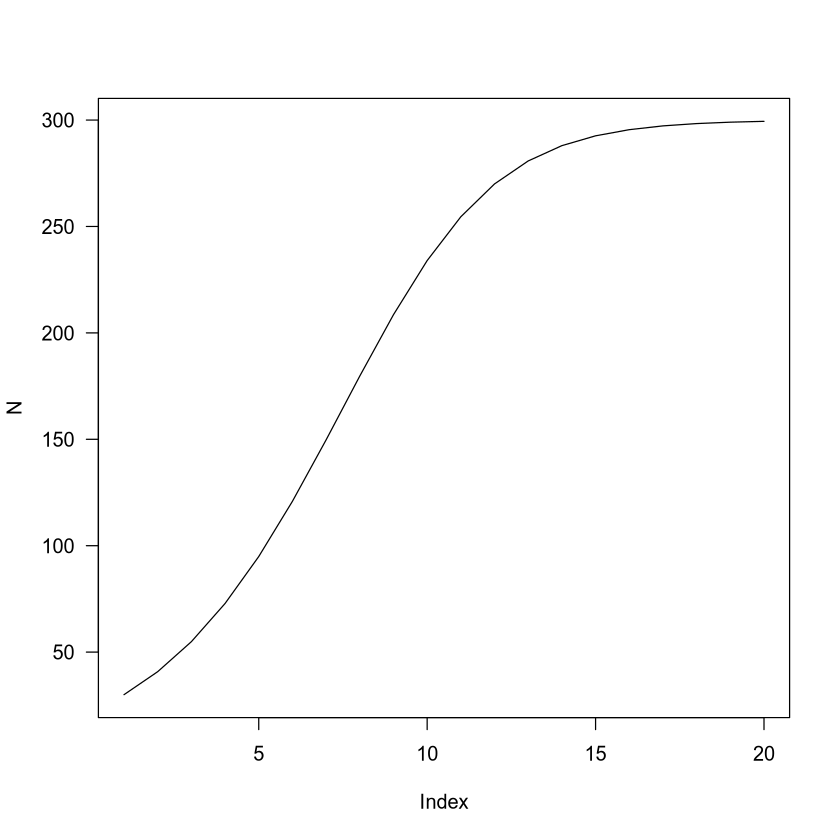

In [6]:
crecimiento2(N1 = 30, r = 0.4, k = 300, tiempo = 20) #si el r es más moderado, no falla.

en general se suelen utilizar integraciones más sofisticadas para obtener el $N(t)$, pero la idea es la misma que hemos visto aqui.

## Contínuas

En general los integradores contínuos generan menos fallos y son más seguros. Veamos cómo podemos implementar modelos en tiempo contínuo.

### 1 especie aislada

De nuevo una especie aislada continuará creciendo indefinidamente de forma exponencial.

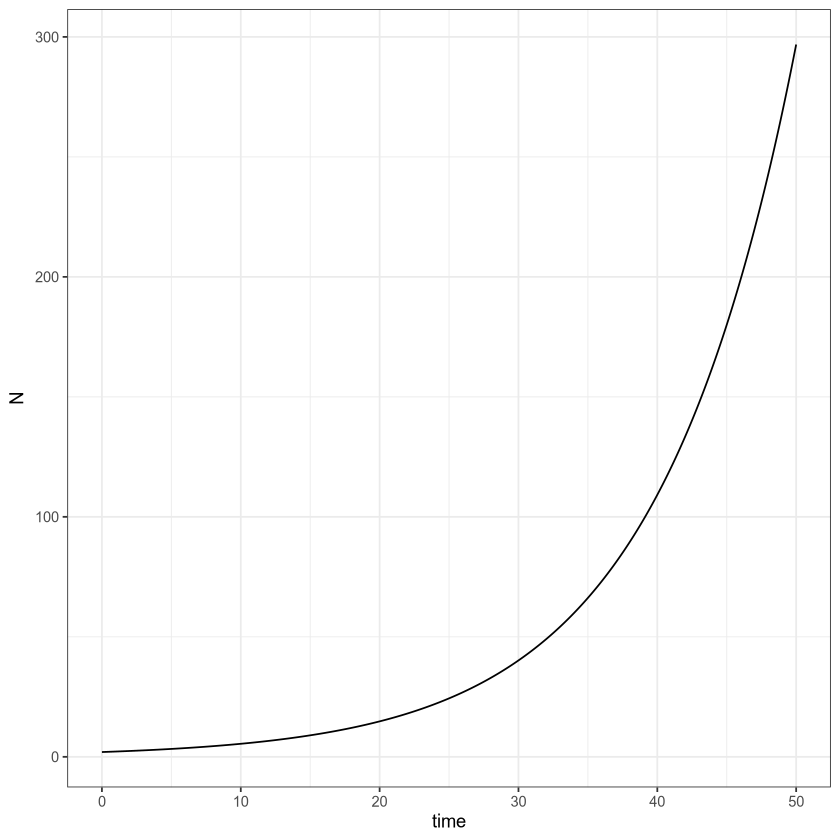

In [7]:
#modelo exponencial de crecimiento
exp_growth <- function(times, y, parms) {
  n <- y[1]          # estado actual: N(t)
  r <- parms[1]      # parámetro: tasa r
  dN.dt <- r * n     # ecuación diferencial: dN/dt = rN # CRECIMIENTO CONSTANTE
  return(list(c(dN.dt)))
}

#parametros de la población
prms <- c(r = 0.1)
init.N <- c(2)
t.s <- seq(0, 50, by = 0.01) #tiempo y escala temporal

#integración del la esuación diferencial
out <- ode(y = init.N, times = t.s, func = exp_growth, parms = prms)
out.df <- as.data.frame(out)
names(out.df)[2] <- "N"

#plot
ggplot(out.df, aes(x = time, y = N)) +
  geom_line() +
  theme_bw()


### 1 especie auto-limitada

Podemos meter un crecimiento dependiende de la población unsando la ecuación logística

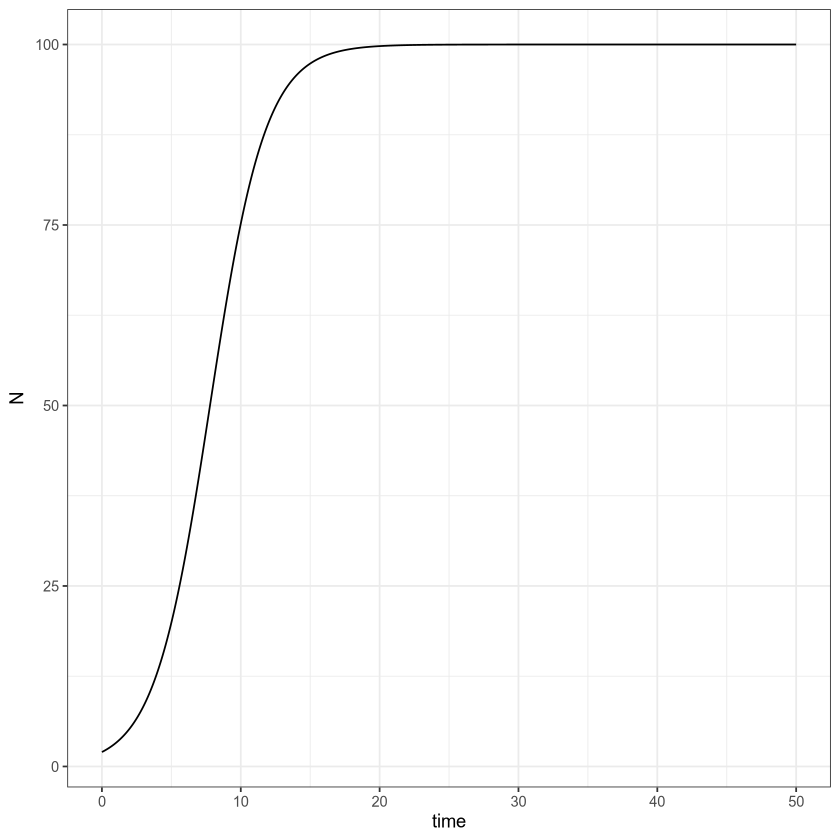

In [8]:
logistic_growth <- function(times, y, parms) {
  n <- y[1]
  r <- parms[1]
  K <- parms[2]
  dN.dt <- r * n * (1 - n/K) #CRECIMIENTO DENSITY DEPENDENT
  return(list(c(dN.dt)))
}

#parametros de la población
prms <- c(r = 0.5,K=100)
init.N <- c(2)
t.s <- seq(0, 50, by = 0.01) #tiempo y escala temporal

#integración del la esuación diferencial
out <- ode(y = init.N, times = t.s, func = logistic_growth, parms = prms)
out.df <- as.data.frame(out)
names(out.df)[2] <- "N"

#plot
ggplot(out.df, aes(x = time, y = N)) +
  geom_line() +
  theme_bw()

## 2 Especies

### Aisladas

Podemos modelar dos especies que tienen creciemiento logístico pero no se ven

[1] 1.0 1.5


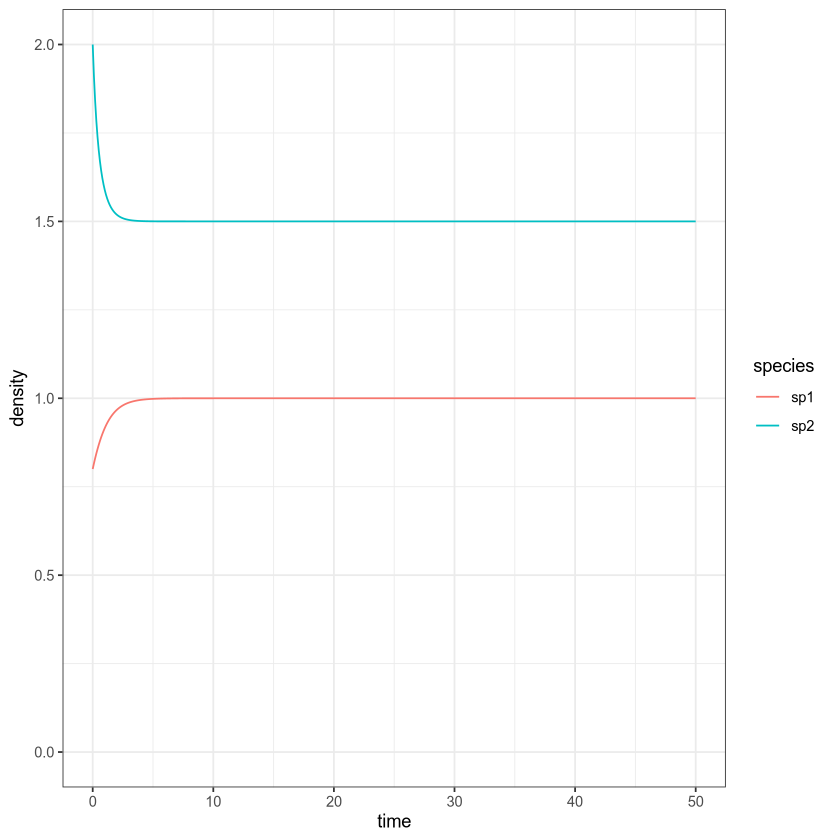

In [9]:
r <- c(1, 1.5)               # r1, r2
a11 <- 1 #diagonal siempre 1
a22 <- 1

A <- matrix(c(-a11, 0,
              0, -a22), 2, 2, byrow = TRUE)

# equilibrio (si A invertible)
x_star <- solve(A, -r)
print(x_star)  # debería ser positivo: c(r1/a11, r2/a22)

x0 <- c(0.8, 2)
res <- integrate_GLV2(r, A, x0, times = seq(0, 50, by = 0.1))

ggplot(res, aes(x = time, y = density, colour = species)) +
  geom_line() +
  coord_cartesian(ylim = c(0, 2)) +
  theme_bw()


### Interaccionando

"enchufamos" las interacciones ($a_{12}$ y $a_{21}$ ya NO son 0).

[1] 0.7777778 1.1111111


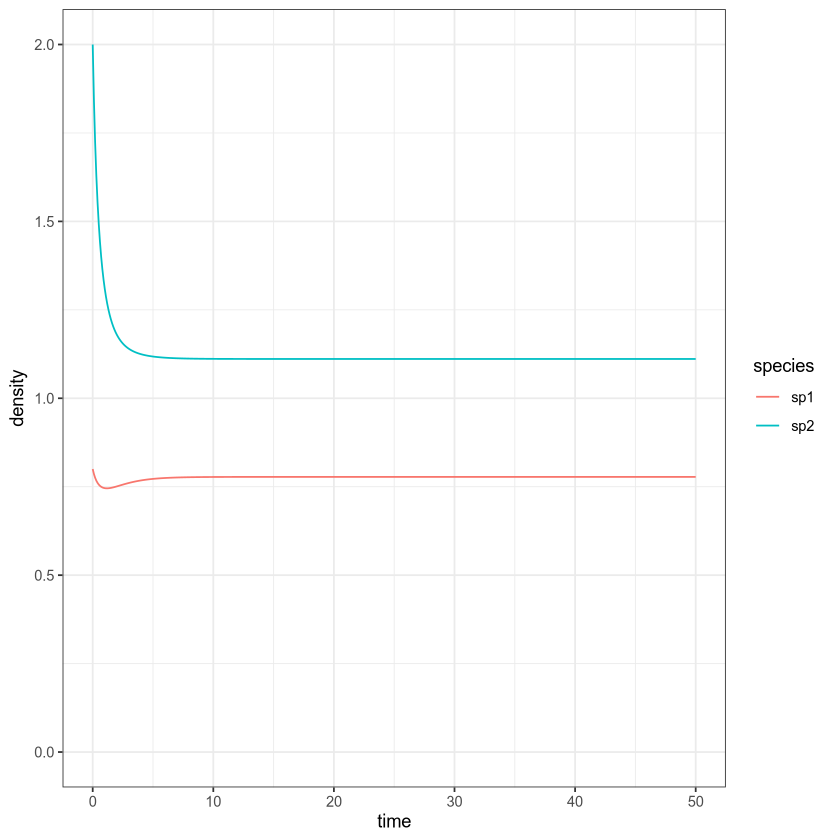

In [10]:
a12=0.2
a21=0.5

A <- matrix(c(-a11, -a12,
              -a21, -a22), 2, 2, byrow = TRUE)

# equilibrio (si A invertible)
x_star <- solve(A, -r)
print(x_star)  # debería ser positivo: c(r1/a11, r2/a22)

x0 <- c(0.8, 2)
res <- integrate_GLV2(r, A, x0, times = seq(0, 50, by = 0.1))

ggplot(res, aes(x = time, y = density, colour = species)) +
  geom_line() +
  coord_cartesian(ylim = c(0, 2)) +
  theme_bw()


Podemos intentar resolver este tipo de sistemas (GLV) de forma analítica como hemos visto

$\vec{N^*} = -\vec{r}\hat{A}^{-1}$

In [11]:
#podemos resolver directamente la ecuación algebraica con la matriz, y en este caso vemos que nos da lo mismo, porque no hay especies que se extinguen
x_star <- solve(A, -r)
x_star

[1] 0.7777778 1.1111111

## N especies

Una vez lo hemos hecho para dos (y hemos visto como meter las interacciones) podemos hacerlo para todas las especies que queramos, usando $A$.

[1] 0.3750000 0.8522727 0.7159091


-1.0,-0.9,-0.5
-0.2,-1.0,-0.8
-0.5,-0.7,-1.0


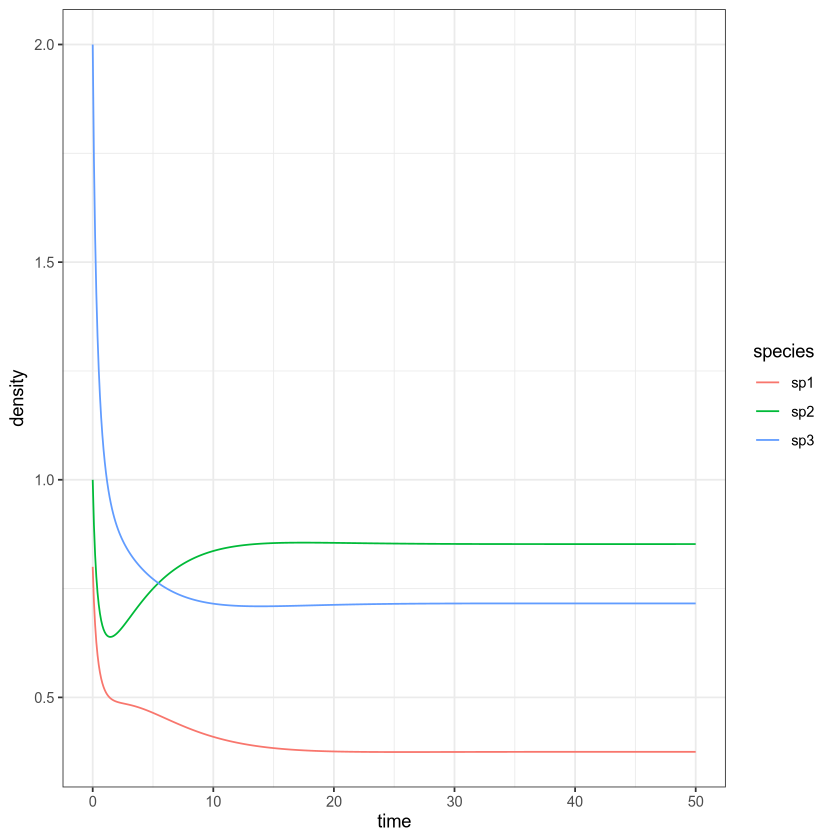

In [16]:
r_1 <- rep(1.5, 3)
A_1 <- -matrix(c(1, 0.9, 0.5, 
                 0.2, 1, 0.8, 
                 0.5, 0.7, 1), 3, 3, byrow = TRUE)

# equilibrio (si A invertible)
x_star <- solve(A_1, -r_1)
print(x_star)  # debería ser positivo: c(r1/a11, r2/a22)

x0 <- c(0.8, 1,2)
res <- integrate_GLV2(r_1, A_1, x0, times = seq(0, 50, by = 0.1))

ggplot(res, aes(x = time, y = density, colour = species)) +
  geom_line() +
  theme_bw()

A_1

[1] 0.189337668 0.096356496 0.010130696 0.409798747 0.113687653 0.071115454
 [7] 0.051913177 0.003378354 0.024456556 0.029825198

 [1] -1.8801155  0.1744288 -0.7468254 -0.2371564  1.3779326 -1.6071510
 [7]  2.2562660 -0.1601723  1.1328316 -0.2740649


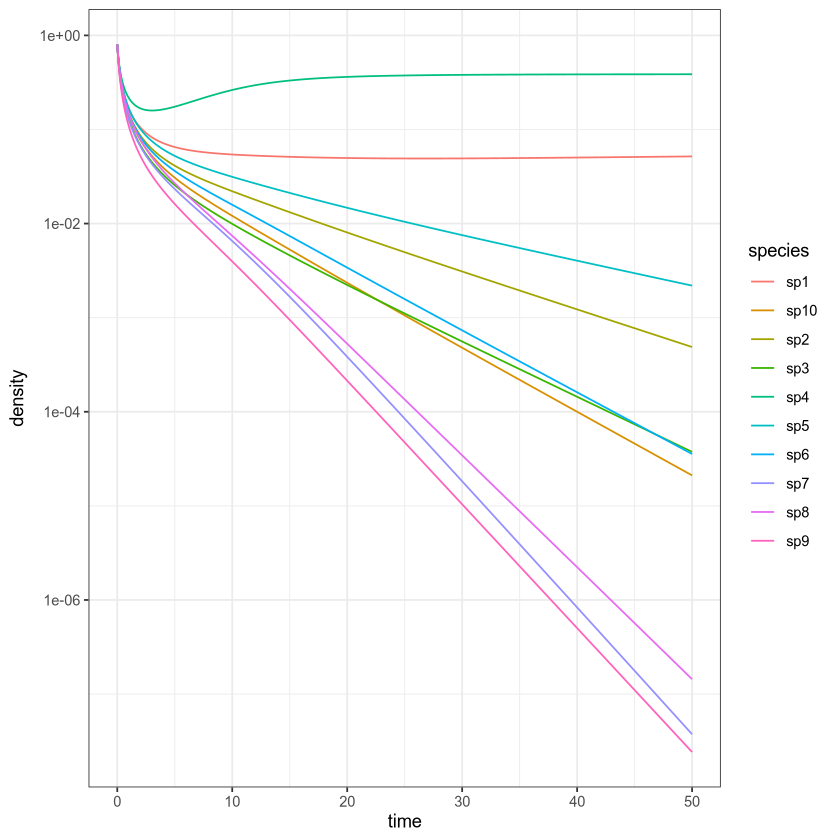

In [52]:
S=10

r<-simplex_sampling(m = 1, n = S)[[1]]
r
A <- -matrix(runif(S*S, 0.2, 0.9), S)
diag(A) <- -1

# equilibrio (si A invertible)
x_star <- solve(A, -r)
print(x_star)  #


x0 <- rep(0.8, S)
res <- integrate_GLV2(r, A, x0, times = seq(0, 50, by = 0.01))

ggplot(res, aes(x = time, y = density, colour = species)) +
  geom_line() +
  scale_y_log10() +
  theme_bw()


<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>

<h3> Exercise 13 </h3>
Vamos a poner una red empírica como base a las matrices de competencia. Para ello vas a usar la proyección de 1 modeo (sobre los polinizaores)  de una red de plnats y polinzadores.

</div>

> Pista: ya hemos visto como sacar estas matrices cont.

Ya sabes cómo cargar la red:

B_Ifilename<-"./Data/Herrera_Donana_ilist.csv"

B_Ilist <- read.csv(B_Ifilename)

B2 <- graph_from_data_frame(B_Ilist, directed = FALSE)


In [ ]:
#cargar red
P_Filename<-"./Data/Medan_Rio_Blanco.csv"
df <- read.csv(P_Filename, row.names = 1)
I <- as.matrix(df)
B <- graph_from_biadjacency_matrix(t(I))


> Pista: También sabes como sacaer la pryeccion de 1 modo. See Lesson 1 , Network representations

In [73]:
# SOLUTION: uncomment line below to load solution
#load_and_show("./snippets/ex13A.R")

> Pista:
now we need to :
- convert ShP (one mode projection) to A: all elements negative and less than 1 (we need to reescale), diagonal = -1
- get a vetor or r (growth rates) of the same length as the number of nodes in A: get Na, generate vector
- get a vector of x0 (initial populations) of the same length as the number of nodes: get NA, generate vector
- Use A, r and X0 in the function we saw before

In [71]:
# SOLUTION: uncomment line below to load solution
#load_and_show("./snippets/ex13B.R")
